<a href="https://colab.research.google.com/github/aarushkote/Myprojects/blob/main/AML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
          from google.colab import files
uploaded =files.upload()

Saving StressLevelDataset.csv to StressLevelDataset.csv


EXP-1

In [ ]:
import pandas as pd
df = pd.read_csv('StressLevelDataset.csv')
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


EXP-2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



df = pd.read_csv('StressLevelDataset.csv')


print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())




(300153, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None
               index       duration      days_left          price
count  300153.000000  300153.000000  300153.000000  300153.000000
mean

EXP-3

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np


df = pd.read_csv('StressLevelDataset.csv')

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print("\nFirst 5 rows:")
print(data.head())


X = data[['duration', 'days_left']]
y = data['price']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Evaluation:")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R² Score:", metrics.r2_score(y_test, y_pred))

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Ticket Price")

line = np.linspace(min(y_test), max(y_test), 180)
plt.plot(line, line, color='red', linewidth=3)

plt.show()




Shape: (1100, 21)
Columns: ['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']

First 5 rows:
   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             14           20                      0          11         2   
1             15            8                      1          15         5   
2             12           18                      1          14         2   
3             16           12                      1          15         4   
4             16           28                      0           7         2   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               1              

KeyError: "None of [Index(['duration', 'days_left'], dtype='object')] are in the [columns]"

EXP-4

Model Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91        76
           1       0.98      0.85      0.91        73
           2       0.81      0.96      0.88        71

    accuracy                           0.90       220
   macro avg       0.91      0.90      0.90       220
weighted avg       0.91      0.90      0.90       220



<Figure size 1200x600 with 0 Axes>

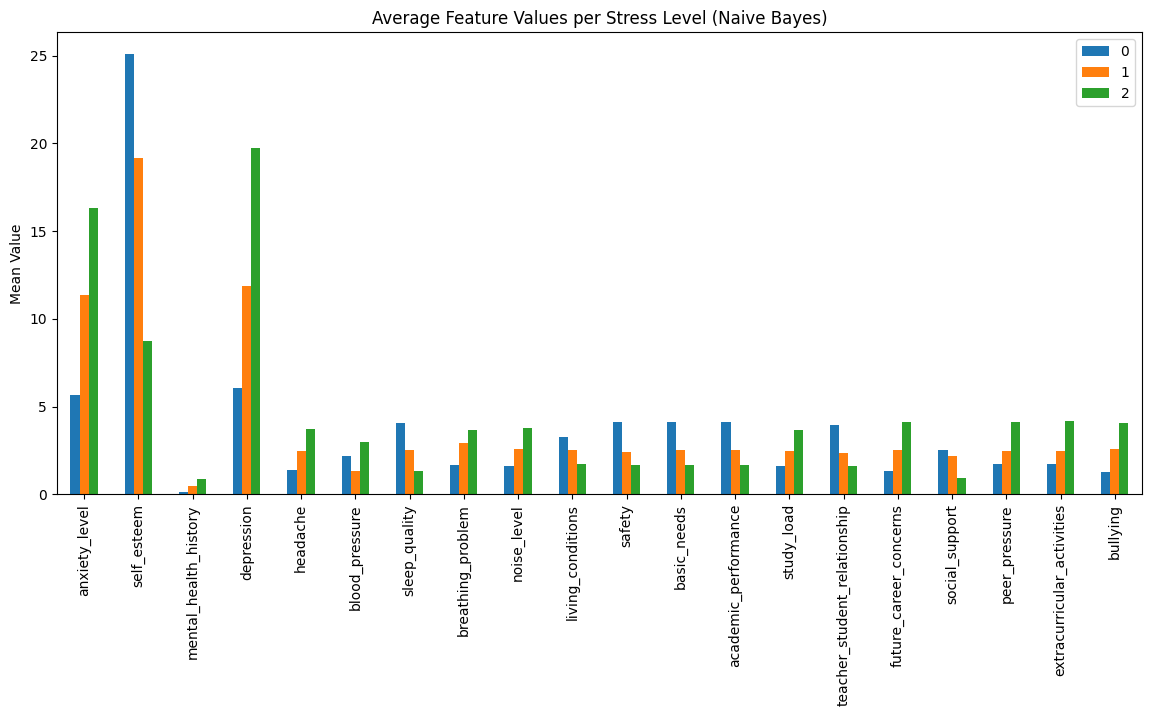

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


data = pd.read_csv("StressLevelDataset.csv")

X = data.drop(columns=['stress_level'])
y = data['stress_level']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


nb = GaussianNB()
nb.fit(X_train, y_train)


y_pred = nb.predict(X_test)


print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


plt.figure(figsize=(12,6))
feature_means = pd.DataFrame(nb.theta_, index=nb.classes_, columns=X.columns).T
feature_means.plot(kind='bar', figsize=(14,6))
plt.title("Average Feature Values per Stress Level (Naive Bayes)")
plt.ylabel("Mean Value")
plt.show()
